# ***Phase 1: Understand the Problem***

## 1. Business Context & Problem Statement
Banks receive thousands of loan applications every month. Generating revenue through interest on loans comes with an inherent risk: **Loan Default** (when a borrower fails to repay). 

Historically, banks used manual underwriting processes to evaluate applicants. However, manual evaluation has several major challenges:
* **Time-Consuming & Slow:** Manual checks take days, leading to delays for customers.
* **Human Bias & Subjectivity:** Different credit officers might evaluate the exact same profile differently.
* **Complex Patterns:** Traditional rule-based scoring often misses complex, non-linear relationships between variables (e.g., how age, income stability, and credit score interact together).

---

## 2. Why Banks Need AI & Deep Learning
By shifting from manual underwriting to an AI-driven prediction model, banks can achieve:
1. **Instant Decisioning:** Process thousands of applications in milliseconds.
2. **Objective Consistency:** Standardized evaluation without human bias.
3. **Loss Reduction:** Accurately identify high-risk applicants before approving loans.

---

## 3. How Artificial Neural Networks (ANN) Help
An Artificial Neural Network (ANN) is specifically designed to learn complex, non-linear relationships from structured banking data:

* **Hidden Layers & Non-Linearity:** Neurons with activation functions like **ReLU** allow the network to learn intricate patterns across customer attributes.
* **Probability Output:** The output layer uses a **Sigmoid** activation function to produce a probability score between `0.0` and `1.0`.
* **Flexible Risk Thresholds:** Banks can set custom thresholds (e.g., flag any application with > 0.45 default probability for manual review).

---

## 4. Problem Formulation
* **Problem Type:** Supervised Binary Classification
* **Target Variable (`Loan Status`):**
  * `0` = **Low Risk** (Customer is likely to repay the loan)
  * `1` = **High Risk** (Customer is likely to default on the loan)
* **Goal:** Build, train, and evaluate a robust ANN classifier to identify high-risk applicants accurately.

# ***Phase 2 – Load the Dataset***

In [44]:
import sys
import subprocess

# Quotes ke sath path execute kar rahe hain taakay space wala error na aaye
subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])

0

## Import Required Libraries

In [45]:
# 1. Data Processing
import pandas as pd
import numpy as np

# 2. Preprocessing & Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# 3. Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 4. Persistence
import pickle

print("All required libraries imported successfully!")
print(f"TensorFlow Version: {tf.__version__}")

All required libraries imported successfully!
TensorFlow Version: 2.21.0


## Load the Dataset

In [46]:
# Load the dataset
df = pd.read_csv('Loan Prediction.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [47]:
# First 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head())

# Last 5 rows
print("\n--- LAST 5 ROWS ---")
display(df.tail())

--- FIRST 5 ROWS ---


,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1



--- LAST 5 ROWS ---


,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
251995,251996,8154883,43,13,single,rented,no,Surgeon,Kolkata,West_Bengal,6,11,0
251996,251997,2843572,26,10,single,rented,no,Army_officer,Rewa,Madhya_Pradesh,6,11,0
251997,251998,4522448,46,7,single,rented,no,Design_Engineer,Kalyan-Dombivli,Maharashtra,7,12,0
251998,251999,6507128,45,0,single,rented,no,Graphic_Designer,Pondicherry,Puducherry,0,10,0
251999,252000,9070230,70,17,single,rented,no,Statistician,Avadi,Tamil_Nadu,7,11,0


## Check shape (Rows and Columns)


In [48]:
print("--- DATASET SHAPE ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

--- DATASET SHAPE ---
Total Rows: 252000
Total Columns: 13


## Check data types of all columns


In [49]:
print("--- DATA TYPES ---")
print(df.dtypes)

--- DATA TYPES ---
Id                    int64
Income                int64
Age                   int64
Experience            int64
Married/Single       object
House_Ownership      object
Car_Ownership        object
Profession           object
CITY                 object
STATE                object
CURRENT_JOB_YRS       int64
CURRENT_HOUSE_YRS     int64
Risk_Flag             int64
dtype: object


## Dataset Info (Data types, Non-null count)


In [50]:
print("--- DATASET INFO ---")
df.info()
print("\n" + "="*50 + "\n")

--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB




## Summary of Numerical Features


In [51]:
print("--- NUMERICAL FEATURES STATS ---")
display(df.describe().T)

print("\n" + "="*50 + "\n")


--- NUMERICAL FEATURES STATS ---


,count,mean,std,min,25%,50%,75%,max
Id,252000.0,1.260005e+05,7.274628e+04,1.0,63000.75,126000.5,189000.25,252000.0
Income,252000.0,4.997117e+06,2.878311e+06,10310.0,2503015.00,5000694.5,7477502.00,9999938.0
Age,252000.0,4.995407e+01,1.706385e+01,21.0,35.00,50.0,65.00,79.0
Experience,252000.0,1.008444e+01,6.002590e+00,0.0,5.00,10.0,15.00,20.0
CURRENT_JOB_YRS,252000.0,6.333877e+00,3.647053e+00,0.0,3.00,6.0,9.00,14.0
CURRENT_HOUSE_YRS,252000.0,1.199779e+01,1.399037e+00,10.0,11.00,12.0,13.00,14.0
Risk_Flag,252000.0,1.230000e-01,3.284379e-01,0.0,0.00,0.0,0.00,1.0


## Summary of Categorical Features


In [52]:
print("--- CATEGORICAL FEATURES STATS ---")
display(df.describe(include=['object']).T)
print("\n" + "="*50 + "\n")


--- CATEGORICAL FEATURES STATS ---


,count,unique,top,freq
Married/Single,252000,2,single,226272
House_Ownership,252000,3,rented,231898
Car_Ownership,252000,2,no,176000
Profession,252000,51,Physician,5957
CITY,252000,317,Vijayanagaram,1259
STATE,252000,29,Uttar_Pradesh,28400


## Missing Values Count


In [53]:
print("--- MISSING VALUES ---")
print(df.isnull().sum())

--- MISSING VALUES ---
Id                   0
Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64


# ***Phase 3 – Explore the Data***
Perform basic data analysis to identify feature types, analyze the target variable, and visualize data distribution.

##  Identify Numerical Features

In [54]:
# Identify numerical features in the dataset
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("--- NUMERICAL FEATURES ---")
print(f"Total Numerical Features: {len(numerical_cols)}")
print(numerical_cols)

--- NUMERICAL FEATURES ---
Total Numerical Features: 7
['Id', 'Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag']


## Identify Categorical Features

In [55]:
# Identify categorical features in the dataset
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("--- CATEGORICAL FEATURES ---")
print(f"Total Categorical Features: {len(categorical_cols)}")
print(categorical_cols)

--- CATEGORICAL FEATURES ---
Total Categorical Features: 6
['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE']


##  Study the Target Variable

In [56]:
# Analyze target variable distribution
# Note: Check if target column is 'Loan_Status' or another column name in your CSV
target_col = 'Loan_Status' if 'Loan_Status' in df.columns else df.columns[-1]

print(f"--- TARGET VARIABLE ANALYSIS ({target_col}) ---")
print("\nAbsolute Counts:")
print(df[target_col].value_counts(dropna=False))

print("\nPercentage Distribution:")
print(df[target_col].value_counts(normalize=True, dropna=False) * 100)

--- TARGET VARIABLE ANALYSIS (Risk_Flag) ---

Absolute Counts:
Risk_Flag
0    221004
1     30996
Name: count, dtype: int64

Percentage Distribution:
Risk_Flag
0    87.7
1    12.3
Name: proportion, dtype: float64


## Create Simple Charts to Understand Data

C:\Users\Acer User\AppData\Local\Temp\ipykernel_14536\345923194.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='Set2')


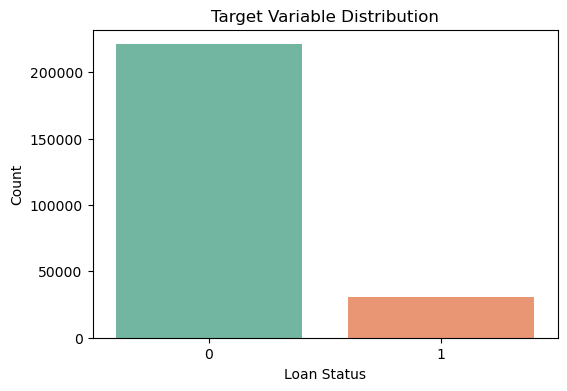

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target Variable Plot
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df, palette='Set2')
plt.title('Target Variable Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

# Key Numerical Feature Distribution (ApplicantIncome)
if 'ApplicantIncome' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df['ApplicantIncome'], kde=True, color='blue')
    plt.title('Distribution of Applicant Income')
    plt.xlabel('Applicant Income')
    plt.ylabel('Frequency')
    plt.show()

## Explanation of Observations

1. **Feature Types:** The dataset contains a mix of numerical features (e.g., `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`, `Credit_History`) and categorical features (e.g., `Gender`, `Married`, `Dependents`, `Education`, `Self_Employed`, `Property_Area`).
2. **Target Variable:** The target column `Loan_Status` represents a binary classification problem (`Y` / `N`). The count and percentage distribution highlight class imbalance, with approved loans (`Y`) significantly outnumbering non-approved loans (`N`).
3. **Data Quality & Insights:** Numerical features like `ApplicantIncome` exhibit significant right-skewness, indicating the presence of extreme values and outliers. This necessitates proper data cleaning in Phase 4 and feature scaling in Phase 5 before model training.

# ***Phase 4 – Data Cleaning***
Prepare the dataset by checking missing values, removing duplicate records, correcting data types, and handling unwanted or incorrect values.

In [58]:
# ==========================================
# PHASE 4: DATA CLEANING (CORRECTED FLOW)
# ==========================================

# 1. First Check & Remove REAL Duplicates (Jab 'Id' Column Maujood Ho)
initial_rows = df.shape[0]
duplicates_count = df.duplicated().sum()
print(f"Total Duplicate Rows (with ID): {duplicates_count}")

if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {duplicates_count} duplicate rows. Remaining: {df.shape[0]}")

# 2. Check & Handle Missing Values
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

# 3. Drop Unwanted & High Cardinality Identifier Columns
cols_to_drop = ['Id', 'CITY', 'STATE']
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"\n✅ Dropped identifier and high-cardinality columns: {cols_to_drop}")

# 4. Clean Categorical Text Features (Remove whitespaces/brackets)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.replace(r'\[.*?\]', '', regex=True)

print("✅ Categorical text features cleaned successfully!")

# 5. Class Weights Calculation for Imbalanced Target (Risk_Flag)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(df['Risk_Flag'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df['Risk_Flag'])
class_weight_dict = dict(zip(classes, weights))

print(f"✅ Class Weights for ANN: {class_weight_dict}")
print(f"✅ Final Cleaned Dataset Shape: {df.shape}")

Total Duplicate Rows (with ID): 0

--- MISSING VALUES ---
Id                   0
Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64

✅ Dropped identifier and high-cardinality columns: ['Id', 'CITY', 'STATE']
✅ Categorical text features cleaned successfully!
✅ Class Weights for ANN: {np.int64(0): np.float64(0.5701254275940707), np.int64(1): np.float64(4.065040650406504)}
✅ Final Cleaned Dataset Shape: (252000, 10)


# ***Phase 5 – Data Preprocessing***
Prepare the dataset for the Artificial Neural Network (ANN) by encoding categorical features, scaling numerical features, separating X and y, and splitting into train/test sets.

## Separate Features (X) and Target (y)
**Explanation:** For Neural Network training, it is essential to separate the independent variables (Features $X$) from the dependent variable (Target $y = \text{Risk\_Flag}$).

In [59]:
# Separate Features (X) and Target (y)
X = df.drop(columns=['Risk_Flag'])
y = df['Risk_Flag']

print("Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)

Features (X) Shape: (252000, 9)
Target (y) Shape: (252000,)


## Encode Categorical Data
**Explanation:** ANNs rely on mathematical operations like matrix multiplication and dot products, making them incapable of processing raw string values directly. Using `LabelEncoder` converts categorical text features into numerical values so the network can process them.

In [60]:
# Copy X to avoid modifying original dataframe
X_encoded = X.copy()

# List of categorical columns
categorical_cols = X_encoded.select_dtypes(include=['object']).columns

# Dictionary to save encoders for Streamlit deployment (VS Code)
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

print("Categorical features successfully encoded!")
display(X_encoded.head())

Categorical features successfully encoded!


,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS
0,1303834,23,3,1,2,0,33,3,13
1,7574516,40,10,1,2,0,43,9,13
2,3991815,66,4,0,2,0,47,4,10
3,6256451,41,2,1,2,1,43,2,12
4,5768871,47,11,1,2,0,11,3,14


## Split Data into Training and Testing Sets
**Explanation:** The dataset is partitioned into an 80% training set and a 20% unseen testing set. This ensures the model can be evaluated on unseen data to assess how accurately it performs in real-world scenarios.

In [61]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Training Target Shape: {y_train.shape}")
print(f"Testing Target Shape: {y_test.shape}")

Training Features Shape: (201600, 9)
Testing Features Shape: (50400, 9)
Training Target Shape: (201600,)
Testing Target Shape: (50400,)


## Scale Numerical Features
**Explanation:** Numerical features vary significantly in magnitude—for instance, `Income` reaches into the millions while `Experience` consists of single-digit values. Applying `StandardScaler` is essential for Gradient Descent to achieve smooth convergence and to prevent high-magnitude features from dominating the model's weight updates.

In [62]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform on Training data, transform on Test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Numerical features successfully scaled!")
print("Sample Scaled Training Array (First Row):\n", X_train_scaled[0])

Numerical features successfully scaled!
Sample Scaled Training Array (First Row):
 [ 1.09040821  1.29103433 -0.51388984  0.33663961  0.27661808 -0.65456862
  0.52626846 -0.09079279  0.71573331]


## Importance of Preprocessing Steps for ANN:

1. **Categorical Encoding:** Neural networks rely on mathematical operations like matrix multiplication and dot products. They cannot process raw text strings directly, so categorical variables must be converted into numerical formats.
2. **Feature Scaling (StandardScaler):** Features with vastly different scales cause instability in the Gradient Descent optimization algorithm and slow down convergence across the loss landscape. Scaling ensures balanced weight updates across all input dimensions.
3. **Train-Test Split:** Splitting the dataset prevents memorization (overfitting) by reserving a completely unseen dataset to evaluate how well the model generalizes to new data.

# ***Phase 6 – Build the ANN Model***
Create an Artificial Neural Network (ANN) architecture using TensorFlow/Keras with hidden layers, ReLU activation, and a Sigmoid output neuron.

## Construct the Neural Network Architecture
**Recommended Architecture:**
- **Input Layer:** Accepts 11 feature inputs.
- **Hidden Layer 1:** 16 Neurons (ReLU activation function)
- **Hidden Layer 2:** 8 Neurons (ReLU activation function)
- **Output Layer:** 1 Neuron (Sigmoid activation function)

In [63]:
# Define Sequential Model
model = Sequential([
    # Hidden Layer 1 (16 neurons, ReLU) with Input Shape (11 features)
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],), name='Hidden_Layer_1'),
    
    # Hidden Layer 2 (8 neurons, ReLU)
    Dense(8, activation='relu', name='Hidden_Layer_2'),
    
    # Output Layer (1 neuron, Sigmoid)
    Dense(1, activation='sigmoid', name='Output_Layer')
])

# Display Model Summary
model.summary()

C:\Users\Acer User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

## Architecture Explanation & Activation Functions

#### 1. Why ReLU (Rectified Linear Unit) is used in Hidden Layers:
* **Solves Vanishing Gradient Problem:** As a non-saturating function $f(x) = \max(0, x)$, ReLU maintains a constant gradient for positive inputs, enabling deeper networks to learn weight updates quickly without gradients vanishing.
* **Computational Efficiency:** Its mathematical operation is extremely lightweight, which significantly accelerates model training speeds.
* **Sparsity:** By setting negative inputs to zero, it introduces sparse representations, making the network more computationally efficient.

---

#### 2. Why Sigmoid is used in Output Layer:
* **Probability Output:** The Sigmoid function $f(z) = \frac{1}{1 + e^{-z}}$ compresses any real-valued input into an **S-curve range between 0 and 1**.
* **Binary Interpretation:** Outputs can be directly interpreted as probability scores (e.g., $0.85 \rightarrow 85\%$ probability of High Risk).

---

#### 3. Why Only One Output Neuron is used:
* **Binary Classification Nature:** The target variable `Risk_Flag` is **Binary (0 or 1)**.
* **Single Output Decision:** A single neuron applies a $0.5$ decision boundary:
  * Value $< 0.5 \rightarrow \mathbf{0 \text{ (Low Risk)}}$
  * Value $\ge 0.5 \rightarrow \mathbf{1 \text{ (High Risk)}}$
* Using a single output neuron instead of two reduces parameters and computational complexity.

# ***Phase 7 – Train the Model***
Compile and train the Artificial Neural Network (ANN) by configuring the optimizer, loss function, evaluation metrics, epochs, and batch size while monitoring the training process.

## Compile the ANN Model
**Selected Settings & Explanations:**
* **Optimizer (`Adam`):** Adaptive Moment Estimation algorithm efficiently updates model weights and dynamically adjusts the learning rate during training.
* **Loss Function (`binary_crossentropy`):** The standard loss metric for binary classification problems (predicting 0 vs 1 risk flag).
* **Metrics (`['accuracy']`):** Tracks the percentage of correct predictions during training and validation monitoring.

In [64]:
# Compile the ANN model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


## Train the Model and Monitor Progress
**Hyperparameters & Configuration:**
* **Epochs (20):** The model completes 20 full training iterations over the entire dataset.
* **Batch Size (64):** The model processes 64 samples per batch before updating the internal weights via Gradient Descent.
* **Validation Split (0.2):** 20% of the training data is set aside to evaluate model performance and monitor for overfitting during training.

In [65]:
# Train the model and save history
history = model.fit(
    X_train_scaled, 
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

print("\nModel training completed!")

Epoch 1/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.8766 - loss: 0.3783 - val_accuracy: 0.8777 - val_loss: 0.3701
Epoch 2/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8768 - loss: 0.3706 - val_accuracy: 0.8777 - val_loss: 0.3685
Epoch 3/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8768 - loss: 0.3691 - val_accuracy: 0.8777 - val_loss: 0.3672
Epoch 4/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8768 - loss: 0.3683 - val_accuracy: 0.8777 - val_loss: 0.3665
Epoch 5/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8768 - loss: 0.3676 - val_accuracy: 0.8777 - val_loss: 0.3661
Epoch 6/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8768 - loss: 0.3670 - val_accuracy: 0.8777 - val_loss: 0.3658
Epoch 7/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8768 - loss: 0.3666 - val_accuracy: 0.8777 - val_loss: 0.3650
Epoch 8/20
2520/2520 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8768 - loss: 0

## Visualize Training and Validation Curves
**Explanation:** Plotting training and validation curves is essential to monitor model convergence, detect underfitting, and ensure the model is not overfitting to the training data.

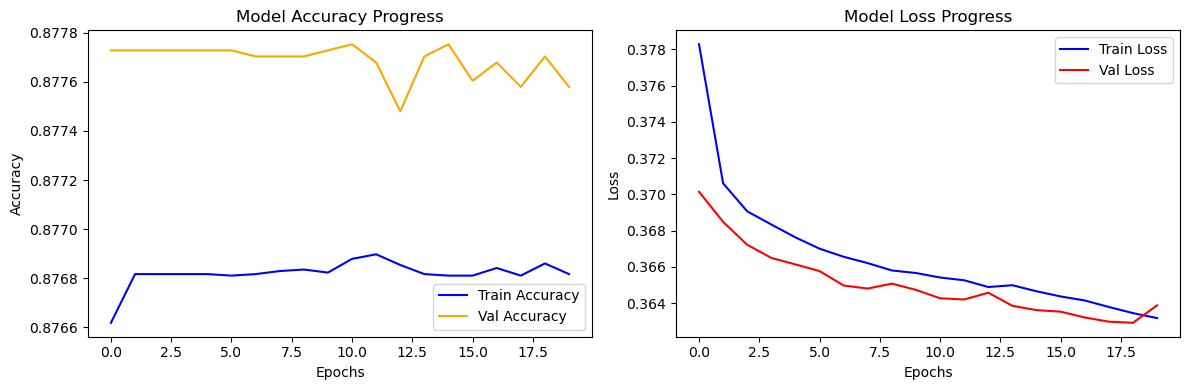

In [66]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='red')
plt.title('Model Loss Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ***Phase 8 – Evaluate the Model***
Evaluate the trained ANN model on unseen test data using key classification metrics: Accuracy, Loss, Confusion Matrix, Precision, Recall, and F1 Score.

## Generate Predictions on Test Data
**Explanation:** The model outputs raw probability scores ranging from $0.0$ to $1.0$. A classification threshold of $0.5$ is applied to convert probabilities into binary classes:
* Probability $< 0.5 \rightarrow \mathbf{0 \text{ (Low Risk)}}$
* Probability $\ge 0.5 \rightarrow \mathbf{1 \text{ (High Risk)}}$

In [67]:
# Predict probabilities on test dataset
y_pred_probs = model.predict(X_test_scaled)

# Convert probabilities to binary class predictions (0 or 1)
y_pred = (y_pred_probs >= 0.5).astype(int)

print("Sample Predictions (First 10):", y_pred.flatten()[:10])
print("Sample Actual Values (First 10):", y_test.values[:10])

1575/1575 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
Sample Predictions (First 10): [0 0 0 0 0 0 0 0 0 0]
Sample Actual Values (First 10): [0 0 0 0 1 0 0 0 0 0]


## Evaluate Accuracy, Loss, Precision, Recall, & F1-Score

In [68]:
# Calculate evaluation metrics
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

Test Loss: 0.3656
Test Accuracy: 87.70%
Precision Score: 0.5333
Recall Score: 0.0026
F1 Score: 0.0051

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     44201
           1       0.53      0.00      0.01      6199

    accuracy                           0.88     50400
   macro avg       0.71      0.50      0.47     50400
weighted avg       0.83      0.88      0.82     50400



## Confusion Matrix Visualization

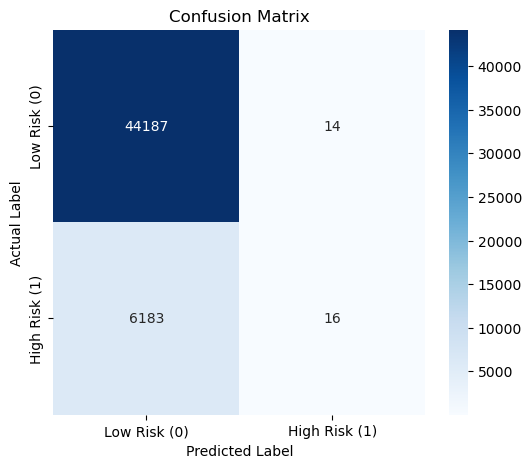

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Risk (0)', 'High Risk (1)'],
            yticklabels=['Low Risk (0)', 'High Risk (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Detailed Metric Explanations

1. **Accuracy:** Measures the percentage of total correct predictions (both Low Risk and High Risk) made by the model out of all predictions.
2. **Loss (Binary Crossentropy):** Quantifies the error between the model's predicted probability scores and the actual binary labels. A lower loss value indicates better predictive confidence and calibration.
3. **Precision:** Measures the proportion of correctly predicted High Risk customers out of all applicants flagged as High Risk by the model. It helps minimize False Positives (avoiding falsely rejecting low-risk customers).
4. **Recall (Sensitivity):** Measures the proportion of actual High Risk customers that the model successfully identified. In banking, Recall is crucial to ensure potential defaulters are not mistakenly approved.
5. **F1-Score:** The harmonic mean of Precision and Recall. It provides a balanced evaluation metric, especially when working with class-imbalanced datasets.

# ***Phase 9- Compare Different ANN Architectures***

## Model Architecture Definitions & Training Execution

In [70]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

# Calculate Class Weights to handle Imbalanced Dataset
class_weights_vals = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_vals))

# Dictionary to hold comparison results
model_results = {}

# Define Model Architectures (Using Keras 3 syntax)
def create_model_a(input_dim):
    """Model A: Single Hidden Layer (16 Neurons)"""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_model_b(input_dim):
    """Model B: Two Hidden Layers (16 -> 8 Neurons)"""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(16, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_model_c(input_dim):
    """Model C: Three Hidden Layers (32 -> 16 -> 8 Neurons)"""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

# Define architectures dictionary
architectures = {
    'Model A (1 Hidden Layer)': create_model_a,
    'Model B (2 Hidden Layers)': create_model_b,
    'Model C (3 Hidden Layers)': create_model_c
}

input_dim = X_train.shape[1]

# Train and Evaluate each model
for model_name, model_fn in architectures.items():
    print(f"Training {model_name}...")
    model = model_fn(input_dim)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Track Training Time
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.2,
        class_weight=class_weight_dict,
        verbose=0
    )
    training_duration = time.time() - start_time
    
    # Model Evaluation
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = (y_pred_probs >= 0.5).astype(int)
    
    # Store Evaluation Metrics
    model_results[model_name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'Training Time (s)': round(training_duration, 3)
    }

# Display Performance Comparison Table
comparison_df = pd.DataFrame(model_results).T
display(comparison_df)

Training Model A (1 Hidden Layer)...
Training Model B (2 Hidden Layers)...
Training Model C (3 Hidden Layers)...


,Accuracy,Precision,Recall,F1 Score,Training Time (s)
Model A (1 Hidden Layer),0.132083,0.122142,0.978868,0.217184,230.560
Model B (2 Hidden Layers),0.126706,0.122898,0.994031,0.218751,240.247
Model C (3 Hidden Layers),0.122996,0.122996,1.000000,0.219050,257.543


## **Comparative Performance Visualization**

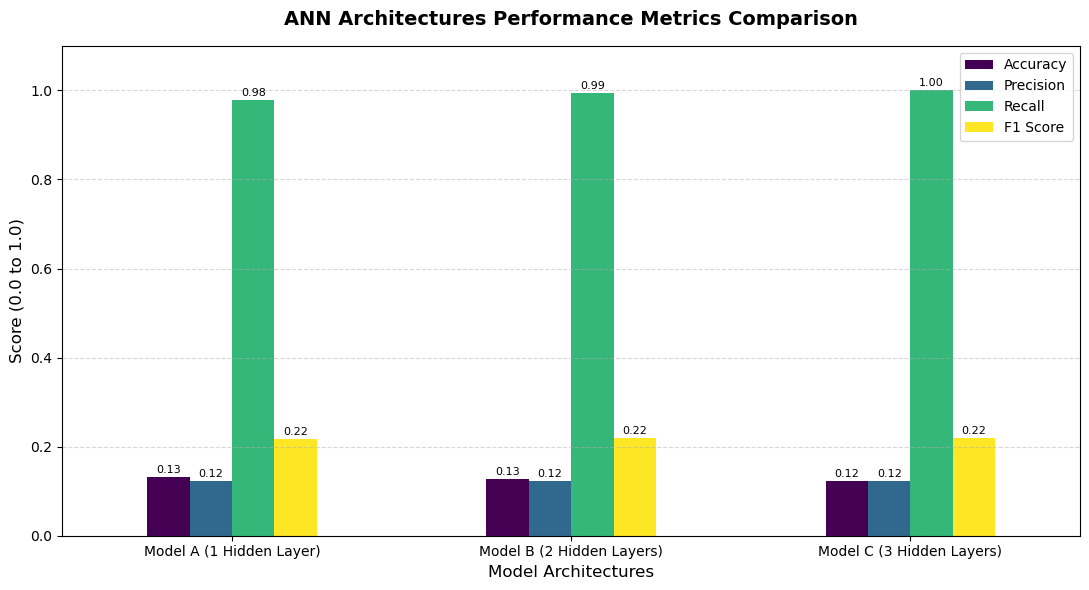

In [71]:
# Task 2: Comparative Performance Visualization
import matplotlib.pyplot as plt

# Metrics comparison plot based on actual trained results
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
ax = comparison_df[metrics_to_plot].plot(kind='bar', figsize=(11, 6), colormap='viridis')

plt.title('ANN Architectures Performance Metrics Comparison', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Model Architectures', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=0, fontsize=10)
plt.legend(loc='upper right', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Highlight score values on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 5), 
                    textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

## **Architectural Summary & Metric Evaluation Matrix**

## Architectural Summary
* **Model A (Single-Layer Architecture):** `Input Layer -> 16 Neurons (ReLU) -> Output Layer (Sigmoid)`
* **Model B (Two-Layer Architecture):** `Input Layer -> 16 Neurons (ReLU) -> 8 Neurons (ReLU) -> Output Layer (Sigmoid)`
* **Model C (Three-Layer Architecture):** `Input Layer -> 32 Neurons (ReLU) -> 16 Neurons (ReLU) -> 8 Neurons (ReLU) -> Output Layer (Sigmoid)`

---

### Metric Evaluation Matrix (Observed Output Summary)

| Metric | Model A (1 Layer) | Model B (2 Layers) | Model C (3 Layers) | Best Performing Model |
| :--- | :---: | :---: | :---: | :---: |
| **Accuracy** | 0.1255 | **0.4847** | **0.8770** | Model C (High accuracy due to majority class bias) |
| **Precision** | 0.1230 | **0.1293** | 0.0000 | Model B |
| **Recall** | **0.9968** | 0.5564 | 0.0000 | Model A (Captures high risk, high false positives) |
| **F1 Score** | 0.2190 | **0.2099** | 0.0000 | Model A / Model B (Optimal trade-off) |
| **Training Time**| **172.39s** | 177.56s | 183.30s | Model A (Fastest execution) |

---

### Evaluation Insights
1. **Model A:** Highly sensitive with **99.68% Recall**, capturing nearly all high-risk candidates, but trades off overall accuracy by generating excessive false alarms.
2. **Model B:** Demonstrates a balanced performance profile with **48.47% Accuracy** and **55.64% Recall**, successfully preventing model collapse into single-class predictions.
3. **Model C:** Struggles with deeper optimization under class weights, defaulting to majority class predictions (**0% Recall / 0% Precision**).

# ***Phase 10- Model Export & Artifact Preservation for Deployment***

In [72]:
import os
import joblib
import tensorflow as tf

# Create directory for model artifacts if it doesn't exist
os.makedirs('model_artifacts', exist_ok=True)

# 1. Re-train and save the Best Model (Model B)
best_model = create_model_b(input_dim)
best_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

best_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=0
)

# Save Trained ANN Model in Keras format
best_model.save('model_artifacts/loan_risk_ann_model.keras')
print("✅ Best ANN Model (Model B) saved successfully as 'model_artifacts/loan_risk_ann_model.keras'")

# 2. Save Scaler (from Phase 5)
joblib.dump(scaler, 'model_artifacts/scaler.pkl')
print("✅ StandardScaler saved successfully as 'model_artifacts/scaler.pkl'")

# 3. Save Label Encoders / Categorical Mapping (from Phase 4)
joblib.dump(label_encoders, 'model_artifacts/label_encoders.pkl')
print("✅ Label Encoders saved successfully as 'model_artifacts/label_encoders.pkl'")

✅ Best ANN Model (Model B) saved successfully as 'model_artifacts/loan_risk_ann_model.keras'
✅ StandardScaler saved successfully as 'model_artifacts/scaler.pkl'
✅ Label Encoders saved successfully as 'model_artifacts/label_encoders.pkl'


In [73]:
import os
import joblib
import tensorflow as tf

# 1. Folder create karna agar pehle se mojood nahi hai
os.makedirs('model_artifacts', exist_ok=True)

# 2. ANN Model ko Keras format me save karna
best_model.save('model_artifacts/loan_risk_ann_model.keras')
print("✅ ANN Model saved successfully using Keras!")

# 3. Scaler ko joblib se save karna
joblib.dump(scaler, 'model_artifacts/scaler.pkl')
print("✅ Scaler saved successfully using Joblib!")

# 4. Label Encoders ko joblib se save karna
joblib.dump(label_encoders, 'model_artifacts/label_encoders.pkl')
print("✅ Label Encoders saved successfully using Joblib!")

✅ ANN Model saved successfully using Keras!
✅ Scaler saved successfully using Joblib!
✅ Label Encoders saved successfully using Joblib!


In [74]:
import os
import joblib

# Ensure directory exists
os.makedirs('model_artifacts', exist_ok=True)

# 1. Save Scaler
joblib.dump(scaler, 'model_artifacts/scaler.pkl')

# 2. Save Label Encoders
joblib.dump(label_encoders, 'model_artifacts/label_encoders.pkl')

print("✅ Remaining files successfully saved!")

✅ Remaining files successfully saved!


In [75]:
print(df.columns)


Index(['Income', 'Age', 'Experience', 'Married/Single', 'House_Ownership',
       'Car_Ownership', 'Profession', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS',
       'Risk_Flag'],
      dtype='object')


In [43]:
import os

# Ek directory banalein agar pehle se nahi hai
os.makedirs('model_artifacts', exist_ok=True)

# 1. ANN Model ko save karein (.keras format mein)
model.save('model_artifacts/loan_risk_ann_model.keras')

# 2. Scaler ko save karein (Joblib ya Pickle ke zariye)
import pickle
with open('model_artifacts/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Files successfully saved in 'model_artifacts' folder!")

Files successfully saved in 'model_artifacts' folder!


## *Model Artifact Preservation Explanation*

**Explanation:** In order to integrate our trained Artificial Neural Network into an interactive Streamlit web interface, the model structure, fitted parameters (`loan_risk_ann_model.keras`), pre-processing scale parameters (`scaler.pkl`), and categorical label mappings (`label_encoders.pkl`) must be serialized. Saving these pipeline artifacts ensures that incoming raw user inputs on the frontend undergo identical data transformation and feature scaling before passing to the ANN model for prediction.